# Bayesian MCMC Unfolding Example

This notebook demonstrates the use of the Bayesian Markov Chain Monte Carlo (MCMC) method for neutron spectrum unfolding using the NUTS (No-U-Turn Sampler) algorithm.

## Key Features of Bayesian MCMC Approach

- **Full Uncertainty Quantification**: Provides 95% credible intervals (HPD - Highest Posterior Density) for each energy bin
- **Automatic Regularization**: Hierarchical modeling can automatically infer regularization parameters from data
- **Convergence Diagnostics**: Built-in R-hat and effective sample size (ESS) metrics
- **Flexible Modeling**: Easy incorporation of complex priors and hyperparameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector

# Check if PyMC is available
try:
    import pymc as pm
    import arviz as az
    MCMC_AVAILABLE = True
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
except ImportError:
    MCMC_AVAILABLE = False
    print("PyMC and ArviZ are required for the MCMC example.")
    print("Install them with: pip install 'bssunfold[mcmc]'")


PyMC version: 6.3.0
ArviZ version: 1.3.0


## Setup Detector with Response Functions

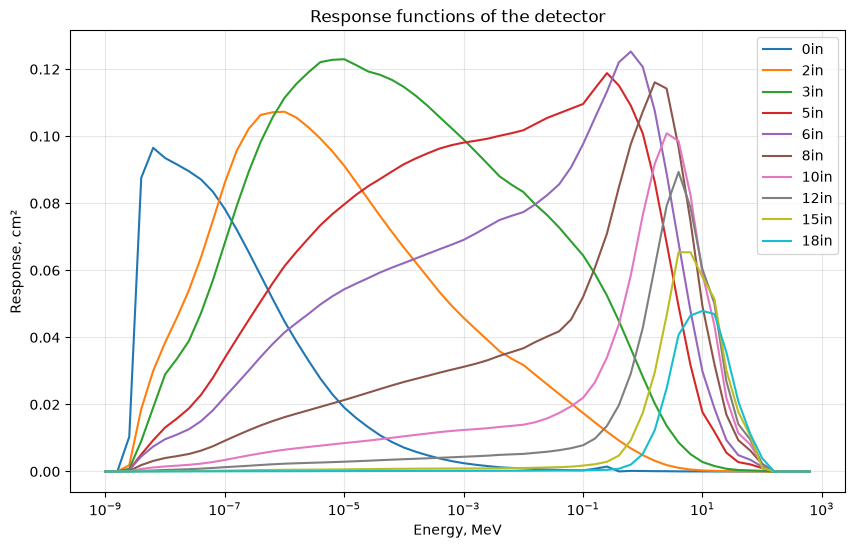

In [2]:
# Load response functions (using GSF default)
from bssunfold import RF_GSF
df = pd.DataFrame.from_dict(RF_GSF, orient='columns')
detector = Detector(df)

# Plot response functions
detector.plot_response_functions()

## Generate Synthetic Readings from Reference Spectrum

We'll use the ISO Cf-252 reference spectrum to generate synthetic detector readings.

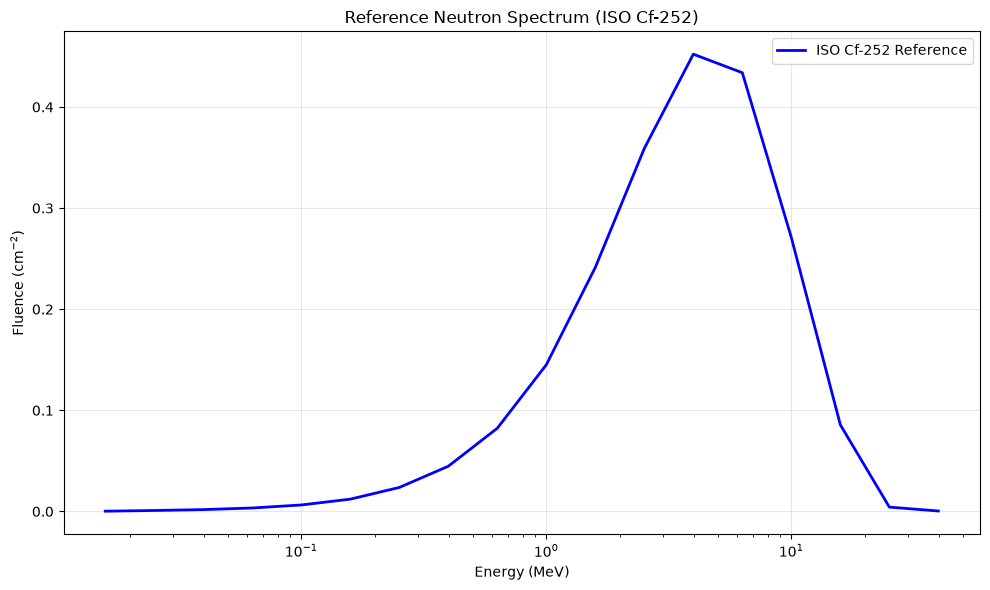

In [12]:
# Reference spectrum ISO Cf-252 (E_MeV grid and fluence are length-matched)
E_ref = np.logspace(-9, 2.8, 60)
Phi_ref = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0002193244132568562, 0.000922, 0.0017977302145640818,
    0.0033934229230273556, 0.00638236969883396, 0.01212580290671056,
    0.0237, 0.04468185467401807, 0.0822779218679577,
    0.1450462719353082, 0.2413649401952857, 0.359,
    0.45221093414611185, 0.4338707690763234, 0.2708850368693928,
    0.0856762250762, 0.00427, 0.0004258199483775139,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
])
assert len(E_ref) == len(Phi_ref), "Energy and fluence grids must match"

# Plot reference spectrum (log scale only over the populated bins)
plt.figure(figsize=(10, 6))
nonneg = Phi_ref > 0
plt.semilogx(E_ref[nonneg], Phi_ref[nonneg], 'b-', linewidth=2,
             label='ISO Cf-252 Reference')
plt.xlabel('Energy (MeV)')
plt.ylabel('Fluence (cm$^{-2}$)')
plt.title('Reference Neutron Spectrum (ISO Cf-252)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Generate Synthetic Detector Readings

We'll calculate what the detectors would measure given this reference spectrum.

In [4]:
# Use only 4 spheres for this example
selected_detectors = ['3in', '5in', '10in', '18in']

# Calculate synthetic readings from reference spectrum
readings = {}
for det_name in selected_detectors:
    # Get response function for this detector
    response = detector.sensitivities[det_name]

    # Interpolate reference spectrum to match response function energy grid
    Phi_interp = np.interp(detector.E_MeV, E_ref, Phi_ref, left=0, right=0)

    # Calculate reading following the package flux-to-counts convention
    reading = np.sum(response * Phi_interp * detector.log_steps)
    readings[det_name] = reading

print("Synthetic detector readings:")
for det, val in readings.items():
    print(f"  {det}: {val:.6f}")


Synthetic detector readings:
  3in: 0.005759
  5in: 0.024303
  10in: 0.035539
  18in: 0.013724


## Perform Bayesian MCMC Unfolding

Now we'll unfold the spectrum using the MCMC method with NUTS sampler.

**Note**: MCMC is computationally intensive. For demonstration purposes, we use fewer samples. In production, use `n_samples=2000` or more for reliable results.

In [5]:
if MCMC_AVAILABLE:
    # Perform MCMC unfolding
    # Using smaller n_samples for faster execution in this example
    result_mcmc = detector.unfold_mcmc(
        readings,
        n_samples=500,       # Number of samples per chain (use 2000+ in production)
        tune=300,            # Number of tuning samples (warmup)
        chains=2,            # Number of independent chains
        target_accept=0.8,   # Target acceptance rate
        use_hierarchical=False,  # Use fixed priors
        random_state=42,     # For reproducibility
        progressbar=True,    # Show progress bar
    )

    print("\nMCMC Unfolding completed!")
    print(f"Method: {result_mcmc['method']}")
    print(f"Residual norm: {result_mcmc['residual_norm']:.6f}")
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [spectrum, sigma]


Output()

Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



MCMC Unfolding completed!
Method: MCMC
Residual norm: 3.564813


## Analyze Results

Let's examine the unfolded spectrum with uncertainty estimates.

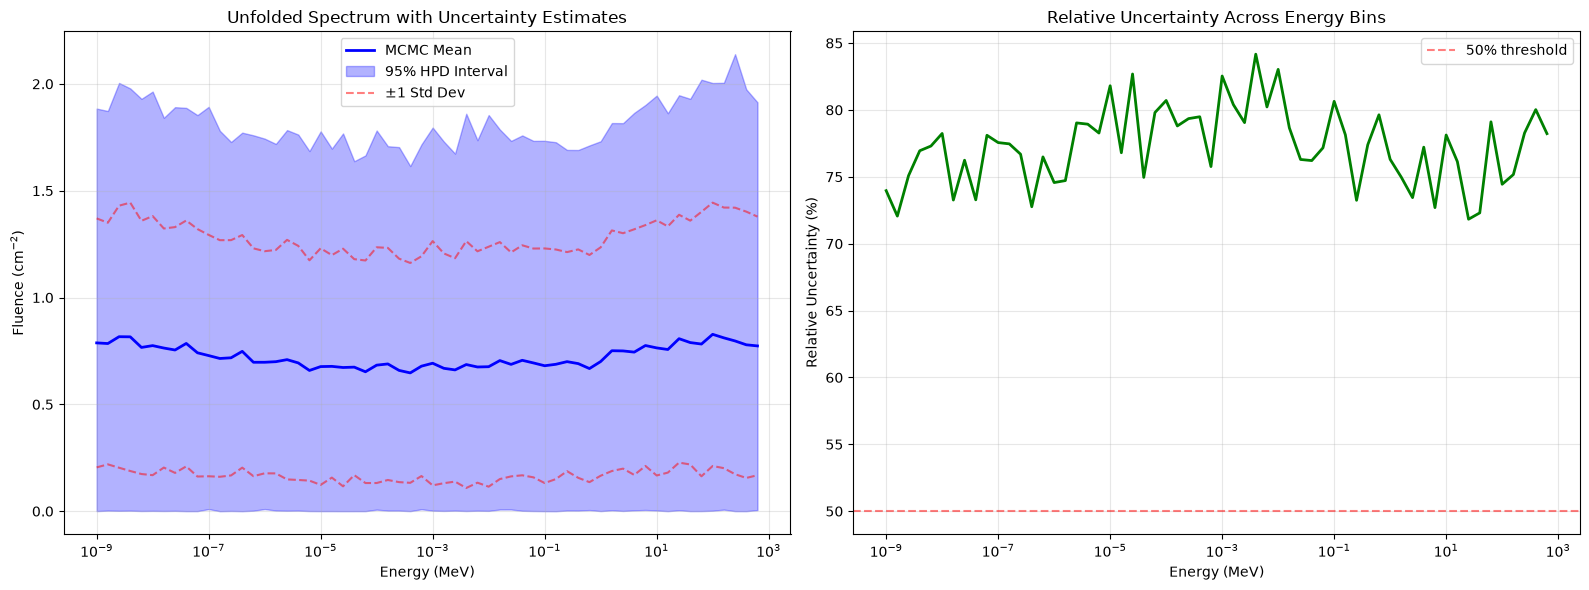

In [13]:
if MCMC_AVAILABLE:
    # Extract results
    energy = result_mcmc['energy']
    spectrum = result_mcmc['spectrum']
    spectrum_std = result_mcmc['spectrum_uncertainty']
    hpd_lower = result_mcmc['spectrum_lower']
    hpd_upper = result_mcmc['spectrum_upper']

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Unfolded spectrum with uncertainty
    ax1.semilogx(energy, spectrum, 'b-', linewidth=2, label='MCMC Mean')
    ax1.fill_between(energy, hpd_lower, hpd_upper, alpha=0.3, color='blue',
                     label='95% HPD Interval')
    ax1.semilogx(energy, spectrum + spectrum_std, 'r--', alpha=0.5,
                 label='\u00b11 Std Dev')
    ax1.semilogx(energy, spectrum - spectrum_std, 'r--', alpha=0.5)
    ax1.set_xlabel('Energy (MeV)')
    ax1.set_ylabel('Fluence (cm$^{-2}$)')
    ax1.set_title('Unfolded Spectrum with Uncertainty Estimates')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')

    # Plot 2: Relative uncertainty
    relative_uncertainty = spectrum_std / spectrum * 100
    relative_uncertainty = np.where(spectrum > 0, relative_uncertainty, 0)

    ax2.semilogx(energy, relative_uncertainty, 'g-', linewidth=2)
    ax2.set_xlabel('Energy (MeV)')
    ax2.set_ylabel('Relative Uncertainty (%)')
    ax2.set_title('Relative Uncertainty Across Energy Bins')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% threshold')
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


## Check Convergence Diagnostics

It's crucial to verify that the MCMC chains have converged properly.

In [7]:
if MCMC_AVAILABLE:
    # Extract MCMC statistics
    mcmc_stats = result_mcmc['mcmc_stats']
    rhat = mcmc_stats['rhat']
    ess = mcmc_stats['ess']

    print("=" * 60)
    print("MCMC Convergence Diagnostics")
    print("=" * 60)
    print(f"Number of chains: {mcmc_stats['n_chains']}")
    print(f"Total samples: {mcmc_stats['n_samples_total']}")
    print(f"Tuning samples: {mcmc_stats['tune_samples']}")
    print(f"Target acceptance rate: {mcmc_stats['target_accept']}")
    print(f"Hierarchical mode: {mcmc_stats['use_hierarchical']}")
    print()
    print("R-hat Statistics (should be < 1.1 for good convergence):")
    print(f"  Min: {rhat.min():.4f}")
    print(f"  Max: {rhat.max():.4f}")
    print(f"  Mean: {rhat.mean():.4f}")
    print()
    print("Effective Sample Size (ESS) Statistics:")
    print(f"  Min: {ess.min():.1f}")
    print(f"  Max: {ess.max():.1f}")
    print(f"  Mean: {ess.mean():.1f}")
    print("=" * 60)

    if rhat.max() < 1.1:
        print("R-hat values indicate good convergence!")
    else:
        print("Some R-hat values exceed 1.1 - consider running more samples")

    if ess.mean() > 100:
        print("ESS values are adequate!")
    else:
        print("ESS values are low - consider running more samples")
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


MCMC Convergence Diagnostics
Number of chains: 2
Total samples: 1000
Tuning samples: 300
Target acceptance rate: 0.8
Hierarchical mode: False

R-hat Statistics (should be < 1.1 for good convergence):
  Min: 0.9992
  Max: 1.0081
  Mean: 1.0022

Effective Sample Size (ESS) Statistics:
  Min: 423.7
  Max: 1132.9
  Mean: 769.4
R-hat values indicate good convergence!
ESS values are adequate!


## Visualize MCMC Traces

Trace plots help visualize the sampling process and check for mixing.

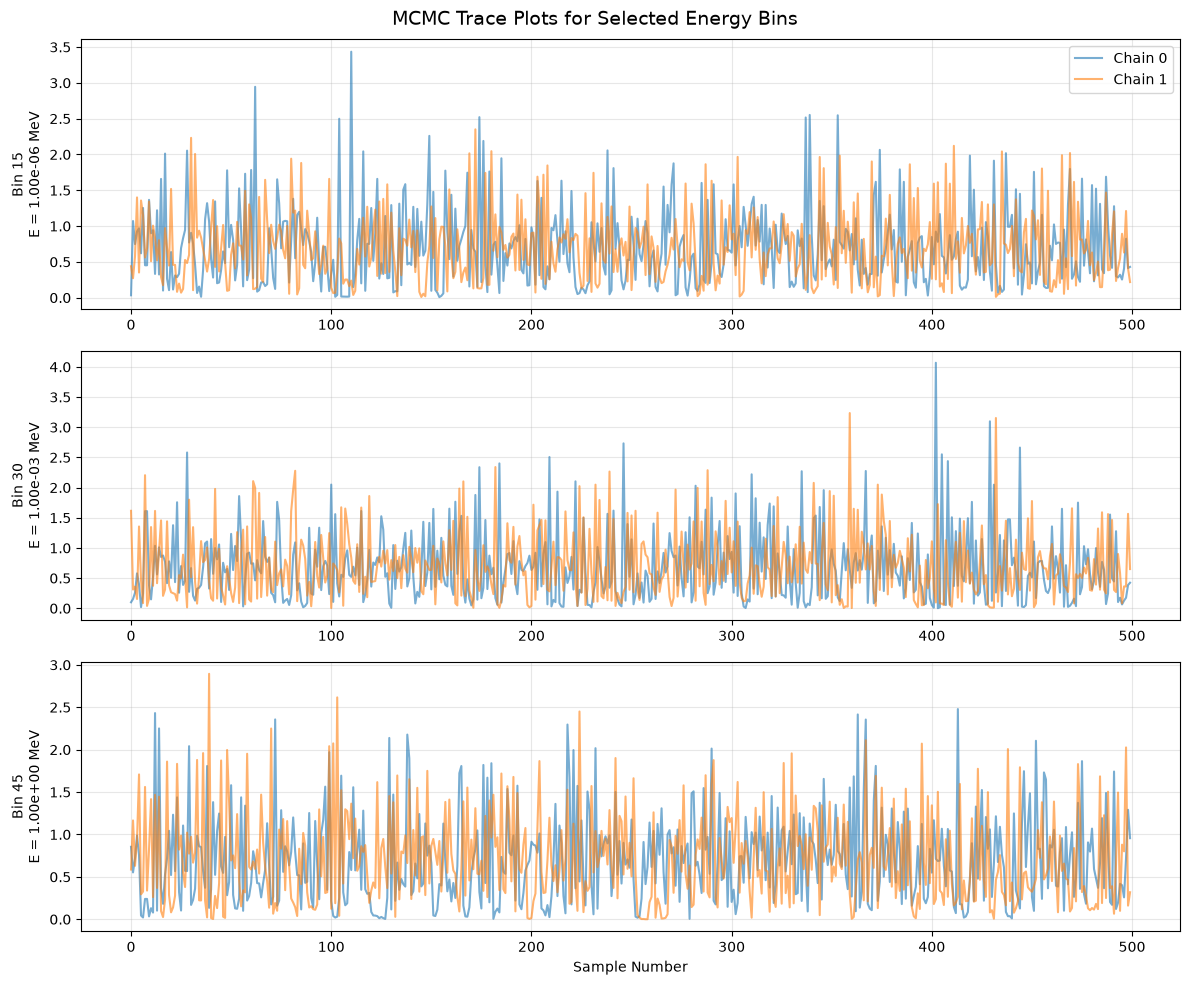

In [8]:
if MCMC_AVAILABLE:
    # Get trace object
    trace = mcmc_stats['trace']

    # Plot traces for a few selected energy bins
    n_energy_bins = len(energy)
    selected_bins = [n_energy_bins // 4, n_energy_bins // 2, 3 * n_energy_bins // 4]

    fig, axes = plt.subplots(len(selected_bins), 1, figsize=(12, 10))
    if len(selected_bins) == 1:
        axes = [axes]

    for idx, bin_idx in enumerate(selected_bins):
        # Extract samples for this energy bin
        samples = trace.posterior['spectrum'].values[:, :, bin_idx]

        # Plot traces for each chain
        for chain in range(samples.shape[0]):
            axes[idx].plot(samples[chain], alpha=0.6, label=f'Chain {chain}')

        axes[idx].set_ylabel(f'Bin {bin_idx}\nE = {energy[bin_idx]:.2e} MeV')
        axes[idx].grid(True, alpha=0.3)
        if idx == 0:
            axes[idx].legend(loc='upper right')

    axes[-1].set_xlabel('Sample Number')
    plt.suptitle('MCMC Trace Plots for Selected Energy Bins', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


## Calculate Dose Rates

The MCMC result includes calculated dose rates from the unfolded spectrum.

In [9]:
if MCMC_AVAILABLE:
    # Extract dose rates
    doserates = result_mcmc['doserates']

    print("Calculated Dose Rates from MCMC Unfolded Spectrum:")
    print("-" * 40)
    for geometry, value in doserates.items():
        print(f"{geometry:8s}: {value:10.4f} pSv cm\u00b2")
    print("-" * 40)
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


Calculated Dose Rates from MCMC Unfolded Spectrum:
----------------------------------------
AP      :  2555.8362 pSv cm²
PA      :  2257.9046 pSv cm²
LLAT    :  1920.6977 pSv cm²
RLAT    :  1842.8911 pSv cm²
ROT     :  2174.3303 pSv cm²
ISO     :  1989.8714 pSv cm²
----------------------------------------


## Comparison with Other Methods

Let's compare MCMC results with other unfolding methods.

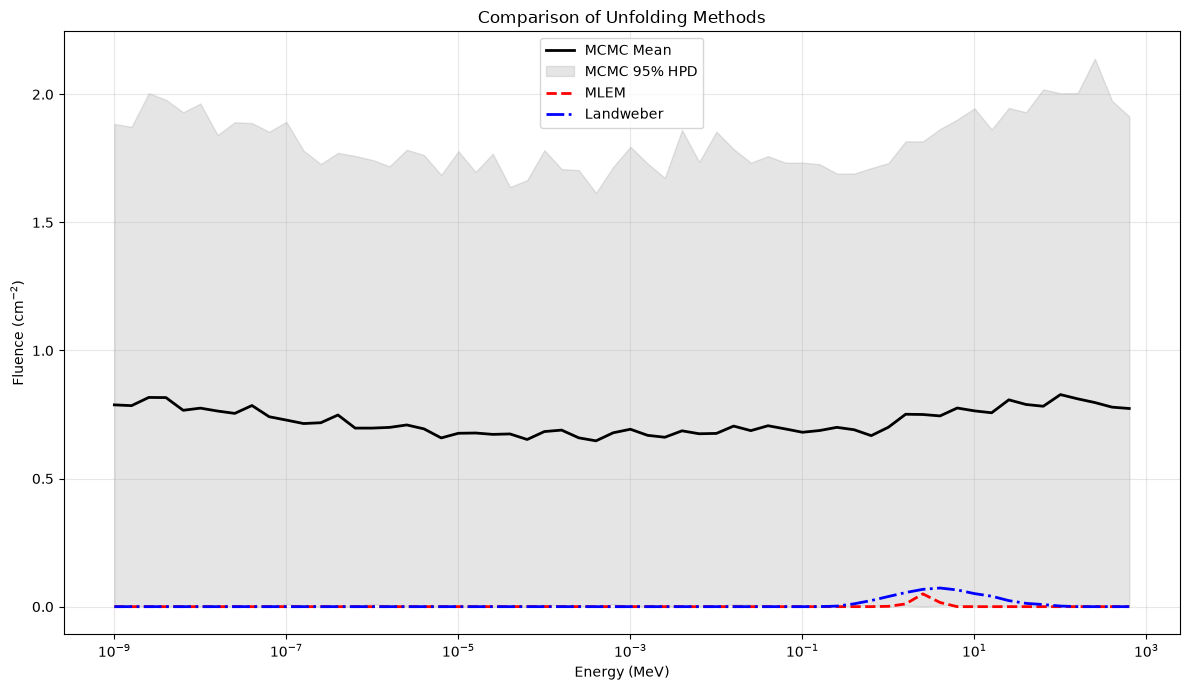

Comparison of residual norms:
  MCMC:       3.564813
  MLEM:       0.035909
  Landweber:  0.000888


In [14]:
if MCMC_AVAILABLE:
    # Try other unfolding methods for comparison
    try:
        result_mlem = detector.unfold_mlem(readings, max_iterations=100)
        result_landweber = detector.unfold_landweber(readings, max_iterations=100)

        fig, ax = plt.subplots(figsize=(12, 7))

        # Plot MCMC with uncertainty
        ax.semilogx(energy, spectrum, 'k-', linewidth=2, label='MCMC Mean')
        ax.fill_between(energy, hpd_lower, hpd_upper, alpha=0.2, color='gray',
                        label='MCMC 95% HPD')

        # Plot other methods
        ax.semilogx(result_mlem['energy'], result_mlem['spectrum'], 'r--',
                    linewidth=2, label='MLEM')
        ax.semilogx(result_landweber['energy'], result_landweber['spectrum'],
                    'b-.', linewidth=2, label='Landweber')

        ax.set_xlabel('Energy (MeV)')
        ax.set_ylabel('Fluence (cm$^{-2}$)')
        ax.set_title('Comparison of Unfolding Methods')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

        plt.tight_layout()
        plt.show()

        print("Comparison of residual norms:")
        print(f"  MCMC:       {result_mcmc['residual_norm']:.6f}")
        print(f"  MLEM:       {result_mlem['residual_norm']:.6f}")
        print(f"  Landweber:  {result_landweber['residual_norm']:.6f}")
    except Exception as e:
        print(f"Could not run comparison: {e}")
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


## Hierarchical Bayesian Model

Let's try the hierarchical model which automatically infers hyperparameters from data.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lambda_hyper, spectrum, sigma]


Output()

Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Hierarchical MCMC completed!
Residual norm: 0.224936


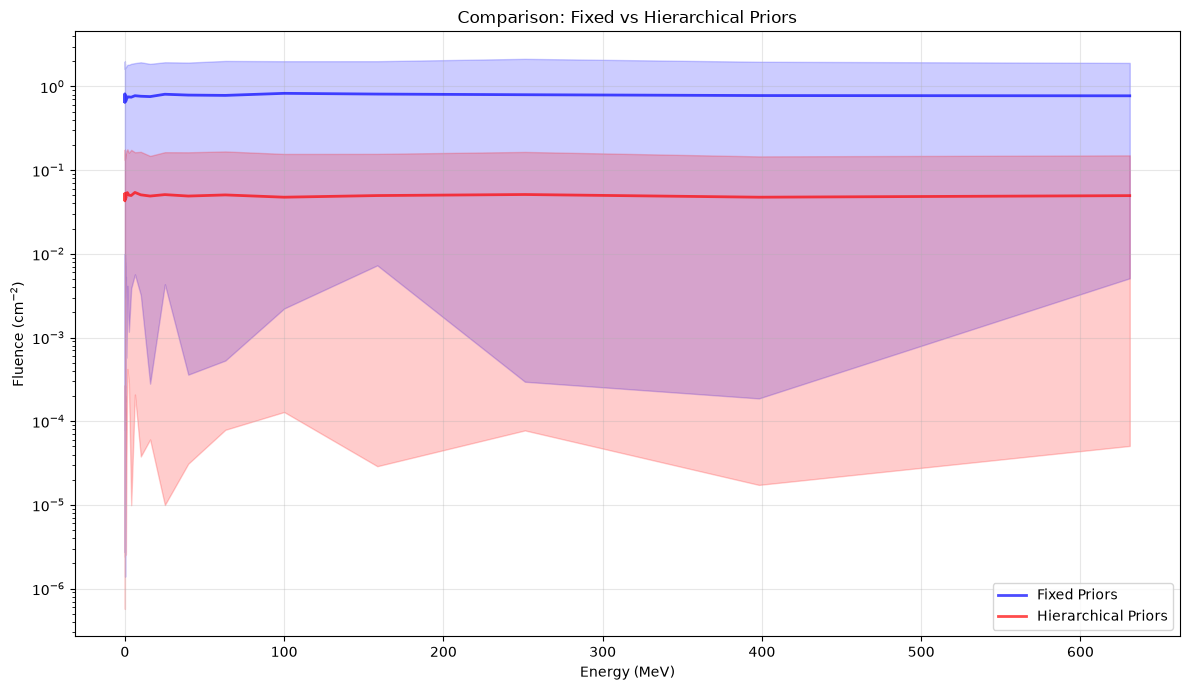

In [11]:
if MCMC_AVAILABLE:
    # Run MCMC with hierarchical priors
    result_hierarchical = detector.unfold_mcmc(
        readings,
        n_samples=500,
        tune=300,
        chains=2,
        use_hierarchical=True,  # Enable hierarchical mode
        random_state=42,
        progressbar=True,
    )

    print("\nHierarchical MCMC completed!")
    print(f"Residual norm: {result_hierarchical['residual_norm']:.6f}")

    # Compare with non-hierarchical
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.semilogy(energy, spectrum, 'b-', linewidth=2, label='Fixed Priors', alpha=0.7)
    ax.fill_between(energy, hpd_lower, hpd_upper, alpha=0.2, color='blue')

    ax.semilogy(result_hierarchical['energy'], result_hierarchical['spectrum'],
                'r-', linewidth=2, label='Hierarchical Priors', alpha=0.7)
    ax.fill_between(result_hierarchical['energy'],
                    result_hierarchical['spectrum_lower'],
                    result_hierarchical['spectrum_upper'],
                    alpha=0.2, color='red')

    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Fluence (cm$^{-2}$)')
    ax.set_title('Comparison: Fixed vs Hierarchical Priors')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    plt.tight_layout()
    plt.show()
else:
    print("MCMC not available - install pymc/arviz to run this cell.")


## Summary

The Bayesian MCMC approach provides:

1. **Full uncertainty quantification** via posterior distributions and HPD intervals
2. **Convergence diagnostics** through R-hat and ESS statistics
3. **Automatic parameter tuning** with hierarchical models
4. **Robust handling** of ill-posed inverse problems

### When to Use MCMC:

- When uncertainty quantification is critical
- For problems where traditional methods give unstable results
- When you need to incorporate prior knowledge formally
- For benchmarking and validation studies

### Computational Considerations:

- MCMC is significantly slower than point-estimate methods (seconds to minutes vs milliseconds)
- Use more samples (`n_samples >= 2000`) for production runs
- Multiple chains (`chains >= 2`) are recommended for convergence assessment
- Hierarchical models add computational cost but provide more robust results

## References

1. Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler: Adaptively Setting Path Lengths in Hamiltonian Monte Carlo. JMLR, 15(1), 1593-1623.

2. Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016). Probabilistic programming in Python using PyMC3. PeerJ Computer Science, 2, e55.

3. Vehtari, A., et al. (2021). Rank-Normalization, Folding, and Localization: An Improved R-hat for Assessing Convergence of MCMC. Bayesian Analysis.